# Here is a simple ReAct Agent with Langraph to perform historical prices analysis:


* Use create_react_agent from LangGraph:
It's based on the agent described in https://arxiv.org/abs/2210.03629 ==> `REACT: SYNERGIZING REASONING AND ACTING IN LANGUAGE MODELS`

ReAct stands for Reasoning and Acting.
To recall the meaning of ReAct paradigm is where LLMs can generate reasoning steps and task-specific actions together in a connected way. The reasoning steps help the model create, adjust, and update action plans while managing exceptions. Meanwhile, the actions let the model interact with external sources, like knowledge bases or environments, to gather more information.

* Add memory saver checkpoint to keep conversation history in the local memory

* Add thread_id if you want to keep track of a given discussion.


✅ Use cases:

I asked several questions:
- "What is the last closing price for NVIDIA, and what date is it for?"
- "Compute the average closing price during the last month"
- "Provide the key statistics for NVIDIA's historical prices over the last six months."
- "Compute the monthly correlation of Nvidia and SP500 during the last year."

✅Tools:

- I added one tool to the agent: `get_stock_prices`



▶ I used Claude-3-5-Sonnet for its ability to handle statistical calculations effectively.



[Hanane Dupouy](https://www.linkedin.com/in/hanane-d-algo-trader)

In [ ]:
!pip install langchain-anthropic langchain-community langgraph -q

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import date
from datetime import datetime

def get_stock_prices(ticker: str, start_date : str, end_date = datetime.today().strftime('%Y-%m-%d')) -> pd.DataFrame:
    """
    Get the historical prices and volume for a ticker from start_date to end_date.

    Args:
      ticker: the stock ticker to be given to yfinance
      start_date: the start date in the format YYYY-MM-DD
      end_date: the end date in the format YYYY-MM-DD
    """
    stock = yf.Ticker(ticker)
    df = yf.download(ticker, start=start_date, end=end_date)

    return df

In [ ]:
datetime.today().strftime('%Y-%m-%d')

'2025-01-15'

In [ ]:
from google.colab import userdata
CLAUDE_API_KEY = userdata.get('CLAUDE_API_KEY')

# Create the ReAct Agent:

In [ ]:
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = ChatAnthropic(model_name="claude-3-5-sonnet-20241022", api_key=CLAUDE_API_KEY)
tools = [get_stock_prices]
agent_executor = create_react_agent(model, tools, checkpointer=memory)

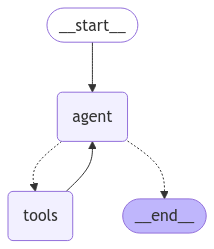

In [ ]:
from IPython.display import Image, display
display(Image(agent_executor.get_graph().draw_mermaid_png()))

# Chat with your agent

In [ ]:
user_query_1 = "What is the last closing price for NVIDIA, and what date is it for?"
user_query_2 = "Compute the average closing price during the last month"
user_query_3 = "Provide the key statistics for NVIDIA's historical prices over the last six months."
user_query_4 = "Compute the monthly correlation of Nvidia and SP500 during the last year."
user_query_5 = "Plot this monthly correlation"
user_query_6 = 'Yes I want a plotting function to be added to the available tools.'

## Query 1

In [ ]:
# Add a thread_id to keep trace of the conversation history related to this given thread_id.
config = {"configurable": {"thread_id": "1"}}

messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_1)}, config)
for m in messages['messages']:
    m.pretty_print()

[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  

In [ ]:
messages['messages'][-1].content

"Based on the data received, NVIDIA's latest closing price is $131.76 as of January 14, 2025. This represents the most recent closing price in the dataset."

## Query 2

In [ ]:
messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_2)}, config)
for m in messages['messages']:
    m.pretty_print()

[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  

In [ ]:
print(messages['messages'][-1].content)

Looking at the closing prices for the last month of trading (from December 14, 2024 to January 14, 2025), I'll calculate the average:

The closing prices are: 132.00, 130.39, 128.91, 130.68, 134.70, 139.67, 140.22, 139.93, 137.01, 137.49, 134.29, 138.31, 144.47, 149.43, 140.14, 140.11, 135.91, 133.23, 131.76

The average closing price over this period is $136.77.

This calculation includes approximately one month of trading days (19 trading days), giving us a good representation of NVIDIA's average closing price over the recent month.


## Query 3

In [ ]:
messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_3)}, config)
for m in messages['messages']:
    m.pretty_print()

[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  

## Query 4

In [ ]:
messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_4)}, config)
for m in messages['messages']:
    m.pretty_print()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  

## Query 5

In [ ]:
messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_5)}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  

## Query 6

In [ ]:
user_query_6 = "Yes I want a plotting function to be added to the available tools."

In [ ]:
messages = agent_executor.invoke({"messages": HumanMessage(content=user_query_6)}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the last closing price for NVIDIA, and what date is it for?
================================== Ai Message ==================================

[{'text': "I'll help you check NVIDIA's (ticker: NVDA) latest closing price. I'll use the stock_prices function which will retrieve this information.", 'type': 'text'}, {'id': 'toolu_01VCMX6k1AEGhVTuneQNZPig', 'input': {'ticker': 'NVDA', 'start_date': '2024-01-01'}, 'name': 'stock_prices', 'type': 'tool_use'}]
Tool Calls:
  stock_prices (toolu_01VCMX6k1AEGhVTuneQNZPig)
 Call ID: toolu_01VCMX6k1AEGhVTuneQNZPig
  Args:
    ticker: NVDA
    start_date: 2024-01-01
================================= Tool Message =================================
Name: stock_prices

Price        Adj Close       Close        High         Low        Open  \
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA   
Date                                                  